In [1]:
import sys
sys.path.append('..')

from ressources.data.description import DESCRIPTIONS

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import category_encoders as ce

In [3]:
def load_db():

    return pd.concat([
        pd.read_parquet(r'..\ressources\data\0_archive\Insurance_Churn_ParticipantsData\train\data-0.parquet'),
        pd.read_parquet(r'..\ressources\data\0_archive\Insurance_Churn_ParticipantsData\train\data-1.parquet'),
        pd.read_parquet(r'..\ressources\data\0_archive\Insurance_Churn_ParticipantsData\train\data-2.parquet')
    ], axis=0).drop_duplicates().reset_index(drop=True)

In [26]:
df = load_db()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2280321 entries, 0 to 2280320
Data columns (total 23 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   INDIVIDUAL_ID           float64
 1   ADDRESS_ID              float64
 2   CURR_ANN_AMT            float64
 3   DAYS_TENURE             float64
 4   CUST_ORIG_DATE          object 
 5   AGE_IN_YEARS            float64
 6   DATE_OF_BIRTH           object 
 7   SOCIAL_SECURITY_NUMBER  object 
 8   ACCT_SUSPD_DATE         object 
 9   INCOME                  float64
 10  HAS_CHILDREN            float64
 11  LENGTH_OF_RESIDENCE     float64
 12  MARITAL_STATUS          object 
 13  HOME_MARKET_VALUE       object 
 14  HOME_OWNER              float64
 15  COLLEGE_DEGREE          float64
 16  GOOD_CREDIT             float64
 17  LATITUDE                float64
 18  LONGITUDE               float64
 19  STREET_ADDRESS          object 
 20  CITY                    object 
 21  STATE                   object 

In [ ]:
f = open('../ressources/data/1_raw/df_raw_description.txt', 'w')
print(df.info(buf=f))
f.close()

None


# Exploration du dataset simulé + sélection de variables

*L'objectif de cette partie est d'explorer les variables disponibles dans le dataset et de dégager avec arguments à l'appui celles qui seront utiles dans la modélisation.*

In [21]:
from utils.fonctions import compute_entropies

def compute_insights(data):
    """Afficher en une fois le taux de na, de nulls et l'entropie."""
    _ = pd.DataFrame(data.isnull().sum(), columns=['null freq'])/data.shape[0]
    _['na freq'] = data.isna().sum()/data.shape[0]
    _['entropy'] = pd.DataFrame(compute_entropies(data, data.columns)).set_index('col')['entropy']
    _ = round(_, 3)
    return _.sort_values(by='entropy')

In [25]:
df.shape

(2280321, 18)

In [14]:
DESCRIPTIONS.get('CURR_ANN_AMT')

'The Annual dollar value paid by the customer. It is not the policy amount. It is actually amount the customer paid during the previous year.'

In [15]:
DESCRIPTIONS.get('ACCT_SUSPD_DATE')

'Day of Account Suspension or Cancellation'

In [32]:
_ = compute_insights(df)

Computing entropies..


In [ ]:
import pickle

with open('../ressources/data/1_raw/df_raw_insights.txt', 'wb') as f:
    pickle.dump(_, f)
_

,null freq,na freq,entropy
STATE,0.000,0.000,0.00
GOOD_CREDIT,0.074,0.074,0.05
COLLEGE_DEGREE,0.074,0.074,0.06
HOME_OWNER,0.074,0.074,0.06
HAS_CHILDREN,0.074,0.074,0.06
MARITAL_STATUS,0.263,0.263,0.07
ACCT_SUSPD_DATE,0.882,0.882,0.07
COUNTY,0.007,0.007,0.11
HOME_MARKET_VALUE,0.157,0.157,0.16
INCOME,0.074,0.074,0.18


*- On calcule l'entropie, le taux de na et le taux de valeurs nulles sur les 23 colonnes du dataset.*<br><br>
*- On obtient que les variables `CURR_ANN_AMT` `INDIVIDUAL_ID` `SOCIAL_SECURITY_NUMBER` `ADDRESS_ID` ont une entropie elevée ce qui suppose une variabilité trop énorme dans les valeurs. Pour les 3 dernières c'est normal car il s'agit de clés primaires. On les retire. En revanche, la première variable `CURR_ANN_AMT` représente la somme totale versée par l'assuré au cours de l'année précédente (ce n'est pas le montant de la police d'assurance). On la garde dans la mesure où il s'agit d'une variable quantitaive qui pourrait s'avérer utile pour la modélisation. A voir lors du feature engineering et de la data viz.*<br><br>
*- la variable `STREET_ADDRESS` contient les adresses des assurés. Elle n'a pas 1 pour entropie car plusieurs assurés peuvent résider à la même adresse. Toutefois, en raison du fait qu'elle est une quasi clé primaire, on pourra la retirer également des variables d'intérêt car elle pourrait rapporter du bruit dans la modélisation.*<br><br>
*-La longitude et la latitude sont simulés donc ils pourraient ne pas apporter d'information pertinente dans la modélisation mais seraient plutôt utiles lors de la phase de dataviz.*<br><br>
*-`STATE` a une entropie nulle, elle ne varie pas et est tout le temps égale à TEXAS, à supprimer.*<br><br>
*- Enfin, la variable `ACCT_SUSPD_DATE` qui représente la date de suspension du contrat a quasiement 88% de valeurs manquantes. On On la supprimera après l'étape de dataviz - elle nous servira a créer notre variable target (88% de personnes n'ayant pas résilié) - en effet lorsque la date d'annulation n'est pas renseignée, le contrat est encore en cours.*<br><br>


In [48]:
txt = f"""
*- On calcule l'entropie, le taux de na et le taux de valeurs nulles sur les 23 colonnes du dataset.*<br><br>
*- On obtient que les variables `CURR_ANN_AMT` `INDIVIDUAL_ID` `SOCIAL_SECURITY_NUMBER` `ADDRESS_ID` ont une entropie elevée ce qui suppose une variabilité trop énorme dans les valeurs. Pour les 3 dernières c'est normal car il s'agit de clés primaires. On les retire. En revanche, la première variable `CURR_ANN_AMT` représente la somme totale versée par l'assuré au cours de l'année précédente (ce n'est pas le montant de la police d'assurance). On la garde dans la mesure où il s'agit d'une variable quantitaive qui pourrait s'avérer utile pour la modélisation. A voir lors du feature engineering et de la data viz.*<br><br>
*- la variable `STREET_ADDRESS` contient les adresses des assurés. Elle n'a pas 1 pour entropie car plusieurs assurés peuvent résider à la même adresse. Toutefois, en raison du fait qu'elle est une quasi clé primaire, on pourra la retirer également des variables d'intérêt car elle pourrait rapporter du bruit dans la modélisation.*<br><br>
*-La longitude et la latitude sont simulés donc ils pourraient ne pas apporter d'information pertinente dans la modélisation mais seraient plutôt utiles lors de la phase de dataviz.*<br><br>
*-`STATE` a une entropie nulle, elle ne varie pas et est tout le temps égale à TEXAS, à supprimer.*<br><br>
*- Enfin, la variable `ACCT_SUSPD_DATE` qui représente la date de suspension du contrat a quasiement 88% de valeurs manquantes. On On la supprimera après l'étape de dataviz - elle nous servira a créer notre variable target (88% de personnes n'ayant pas résilié) - en effet lorsque la date d'annulation n'est pas renseignée, le contrat est encore en cours.*<br><br>
*- On passe donc de 23 à 17 variables d'intérêt à la fin de cette étape.*<br><br>
"""

from unidecode import unidecode
txt = unidecode(txt)

with open('../ressources/data/2_intermediary/var_selection_step1.txt', 'w') as f:
    f.write(txt.encode('utf-8').decode('utf-8'))

In [35]:
df.columns

Index(['INDIVIDUAL_ID', 'ADDRESS_ID', 'CURR_ANN_AMT', 'DAYS_TENURE',
       'CUST_ORIG_DATE', 'AGE_IN_YEARS', 'DATE_OF_BIRTH',
       'SOCIAL_SECURITY_NUMBER', 'ACCT_SUSPD_DATE', 'INCOME', 'HAS_CHILDREN',
       'LENGTH_OF_RESIDENCE', 'MARITAL_STATUS', 'HOME_MARKET_VALUE',
       'HOME_OWNER', 'COLLEGE_DEGREE', 'GOOD_CREDIT', 'LATITUDE', 'LONGITUDE',
       'STREET_ADDRESS', 'CITY', 'STATE', 'COUNTY'],
      dtype='object')

In [ ]:
_cols_to_drop = ['INDIVIDUAL_ID', 'SOCIAL_SECURITY_NUMBER', 'ADDRESS_ID', 'STREET_ADDRESS', 'STATE']
df = df.drop(_cols_to_drop, axis=1)
compute_insights(df) # faire le point

# Lignes avec des valeurs manquantes

*- Par la suite on va regarder en détail les autres variables qui ont des valeurs manquantes :*
- `AGE` : 160k assurés dont l'age est Nan - on peut essayer une imputation/(recalcul car on a la `DATE OF BIRTH` pas de null) dans la mesure ou ca ne représente que 5% du dataset. Mais attention parce qu'il y a des ages abberants (exple 112 ans pour un conducteur de voiture). On fera l'imputation seulement après la dataviz.
- `INCOME`: 160k (même nombre que age) - à voir si ce sont les mêmes - stratégie d'imputation aussi sinon
- `HAS_CHILDREN`: 160k aussi sachant que les modalités yes/no sont bien renseignées - ne pas faire d'imputation
- `LENGTH_OF_RESIDENCE` et `HOME_OWNER` et `COLLEGE_DEGREE` et `GOOD_CREDIT`: 160k 
- `MARITAL STATUS`: une proportion de None différente (599k) - encoder par 'non renseigné'
- `HOME MARKET VALUE`: une proportion différente (357k) - tenter imputation si dataviz ok (car on regrade dans un même périmètre géographique) - ou prédire avec les caractériqtiques géographiques

In [73]:
txt = f"""
VALEURS MANQUANTES
--------------------------------------------

*- Par la suite on va regarder en détail les autres variables qui ont des valeurs manquantes :*
- `AGE` : 160k assurés dont l'age est Nan - on peut essayer une imputation/(recalcul car on a la `DATE OF BIRTH` pas de null) dans la mesure ou ca ne représente que 5% du dataset. Mais attention parce qu'il y a des ages abberants (exple 112 ans pour un conducteur de voiture). On fera l'imputation seulement après la dataviz.
- `INCOME`: 160k (même nombre que age) - à voir si ce sont les mêmes - stratégie d'imputation aussi sinon
- `HAS_CHILDREN`: 160k aussi sachant que les modalités yes/no sont bien renseignées - ne pas faire d'imputation
- `LENGTH_OF_RESIDENCE` et `HOME_OWNER` et `COLLEGE_DEGREE` et `GOOD_CREDIT`: 160k 
- `MARITAL STATUS`: une proportion de None différente (599k) - encoder par 'non renseigné'
- `HOME MARKET VALUE`: une proportion différente (357k) - tenter imputation si dataviz ok (car on regrade dans un même périmètre géographique) - ou prédire avec les caractériqtiques géographiques

Conclusion partielle :
--------------------------------------------
*D'après les colonnes qui manquent, on peut conclure que <u>les 160k sont des assurés dont on n'a pas les vraiables socio démographiques</u>.<br>
On aurait pu tenter de prédire la variable `HOME_MARKET_VALUE` à partir des autres mais il manque aussi les cactériqties de la maison (nas).<br>
On peut tenter de faire une imputation pour garder la data coute que coute mais on ne fera pas. Plutot faire un drop car cela représente juste 5% du dataset.<br>
Une imputation ne rajouterait pas de la qualité au dataset.*
"""
from unidecode import unidecode
txt = unidecode(txt)

with open('../ressources/data/2_intermediary/var_selection_step2.md', 'w') as f:
    f.write(txt.encode('utf-8').decode('utf-8'))

In [42]:
for c in list(_.index):
    if _.loc[c, 'null freq'] > 0:
        print(df[c].value_counts(dropna=False), end='\n'+'='*50+'\n')

GOOD_CREDIT
1.0    1731402
0.0     381153
NaN     167766
Name: count, dtype: int64
COLLEGE_DEGREE
0.0    1475376
1.0     637179
NaN     167766
Name: count, dtype: int64
HOME_OWNER
1.0    1475329
0.0     637226
NaN     167766
Name: count, dtype: int64
HAS_CHILDREN
0.0    1196696
1.0     915859
NaN     167766
Name: count, dtype: int64
MARITAL_STATUS
Married    1048453
Single      632456
None        599412
Name: count, dtype: int64
ACCT_SUSPD_DATE
None          2011062
2022-03-17        977
2022-08-14        971
2022-09-20        970
2021-12-10        967
               ...   
2022-03-25        836
2022-07-26        831
2022-06-20        828
2022-04-20        827
2022-11-09        811
Name: count, Length: 301, dtype: int64
COUNTY
Dallas      865587
Tarrant     658923
Collin      291553
Denton      248770
Ellis        57850
Kaufman      41896
Parker       31827
Rockwall     30634
Johnson      30616
None         17009
Hunt          2273
Cooke         1994
Navarro        743
Grayson        5

*Pour la suite on va s'attarder sur les 160k et voir s'ils ont des traits communs*

<font color=red>Rencherir ici avec des graphqiues avant et après.. et calculer zscore etc..</font>

In [68]:
tmp_df = df[df['AGE_IN_YEARS'].isna()]
compute_insights(tmp_df)

Computing entropies..


,null freq,na freq,entropy
LENGTH_OF_RESIDENCE,1.000,1.000,-0.00
GOOD_CREDIT,1.000,1.000,-0.00
COLLEGE_DEGREE,1.000,1.000,-0.00
AGE_IN_YEARS,1.000,1.000,-0.00
HOME_OWNER,1.000,1.000,-0.00
INCOME,1.000,1.000,-0.00
HAS_CHILDREN,1.000,1.000,-0.00
HOME_MARKET_VALUE,1.000,1.000,-0.00
MARITAL_STATUS,1.000,1.000,-0.00
ACCT_SUSPD_DATE,0.881,0.881,0.09


*D'après llrs colonnes qui manquent, on peut conclure que <u>les 160k sont des assurés dont on n'a pas les vraiables socio démographiques</u>. On aurait pu tenter de prédire la variable `HOME_MARKET_VALUE` à partir des autres mais il manque aussi les cactériqties de la maison (nas). On peut tenter de faire une imputation pour garder la data coute que coute mais on ne fera pas. Plutot faire un drop car cela représente juste 5% du dataset. Une imputation ne rajouterait pas de laqualité au dataset.*

In [ ]:
df.shape

(2280321, 18)

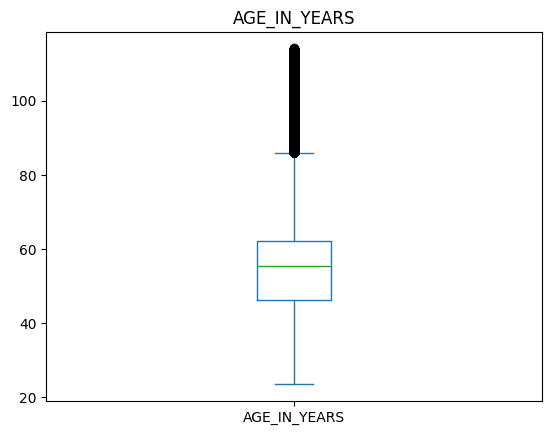

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

df['AGE_IN_YEARS'].plot(kind='box').set_title('AGE_IN_YEARS')
plt.savefig('../ressources/data/2_intermediary/boxplot_age_raw.png')

In [ ]:
df.select_dtypes(exclude='object').columns

Index(['CURR_ANN_AMT', 'DAYS_TENURE', 'AGE_IN_YEARS', 'INCOME', 'HAS_CHILDREN',
       'LENGTH_OF_RESIDENCE', 'HOME_OWNER', 'COLLEGE_DEGREE', 'GOOD_CREDIT',
       'LATITUDE', 'LONGITUDE'],
      dtype='object')

In [69]:
df = df.drop(list(tmp_df.index), axis=0)

In [ ]:
df.shape

(2112555, 18)

In [74]:
df = df.reset_index(drop=True)
df.head()

,CURR_ANN_AMT,DAYS_TENURE,CUST_ORIG_DATE,AGE_IN_YEARS,DATE_OF_BIRTH,ACCT_SUSPD_DATE,INCOME,HAS_CHILDREN,LENGTH_OF_RESIDENCE,MARITAL_STATUS,HOME_MARKET_VALUE,HOME_OWNER,COLLEGE_DEGREE,GOOD_CREDIT,LATITUDE,LONGITUDE,CITY,COUNTY
0,818.877997,1454.0,2018-12-09,44.474,1978-06-23,None,22500.0,1.0,15.0,Married,50000 - 74999,1.0,1.0,1.0,32.578829,-96.305006,Kaufman,Kaufman
1,974.199182,1795.0,2018-01-02,72.559,1950-05-30,None,27500.0,0.0,2.0,Single,50000 - 74999,1.0,0.0,0.0,32.732209,-97.000893,Grand Prairie,Dallas
2,967.375112,4818.0,2009-09-23,55.444,1967-07-07,None,42500.0,0.0,10.0,Married,75000 - 99999,1.0,0.0,0.0,32.819777,-96.846938,Dallas,Dallas
3,992.409561,130.0,2022-07-25,53.558,1969-05-25,2021-12-22,125000.0,1.0,6.0,Married,175000 - 199999,1.0,0.0,1.0,32.684065,-97.162180,Arlington,Tarrant
4,784.633494,5896.0,2006-10-11,50.220,1972-09-25,None,87500.0,1.0,4.0,Married,225000 - 249999,1.0,1.0,1.0,32.751398,-97.376745,Fort Worth,Tarrant


In [ ]:
df.to_parquet(r'..\ressources\data\0_archive\Insurance_Churn_ParticipantsData\train\data-cleaned-before-eda.parquet', compression='gzip')

# Création de la variable target

In [75]:
DESCRIPTIONS.get('ACCT_SUSPD_DATE')

txt = f"""
LOGIQUE : les personnes dont la date est dispo/renseignée sont celles qui ont résilié. Si la date de suspension est manquante (NA) c'est que la personne est toujours en portefeuille.
On peut donc créer une variable target churn = 1 si la date est renseignée et churn = 0 sinon.
"""
# => t'as résilié donc isna == not churn 
txt = unidecode(txt)
with open('../ressources/data/2_intermediary/target_creation.txt', 'w') as f:
    f.write(txt)

In [76]:
df['churn'] = ~df['ACCT_SUSPD_DATE'].isna() # si ta date est dispo => t'as résilié donc isna == not churn 

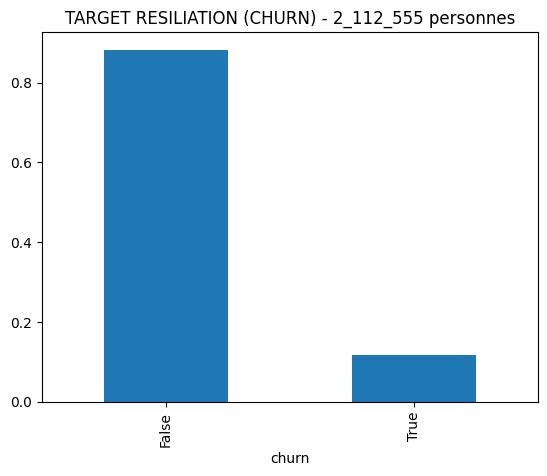

In [79]:
df.churn.value_counts(normalize=True).plot(kind='bar').set_title(f'TARGET RESILIATION (CHURN) - {df.shape[0]:_} personnes')
plt.savefig('../ressources/data/2_intermediary/target_resiliation_creation.png')
plt.show()

*On a clairement un déséquilibre de classes à traiter plus tard...*

In [80]:
compute_insights(df)

Computing entropies..


,null freq,na freq,entropy
churn,0.000,0.000,0.02
GOOD_CREDIT,0.000,0.000,0.03
COLLEGE_DEGREE,0.000,0.000,0.04
HOME_OWNER,0.000,0.000,0.04
HAS_CHILDREN,0.000,0.000,0.05
MARITAL_STATUS,0.204,0.204,0.07
ACCT_SUSPD_DATE,0.882,0.882,0.07
COUNTY,0.007,0.007,0.11
HOME_MARKET_VALUE,0.090,0.090,0.17
INCOME,0.000,0.000,0.18


# Pré traitement (suite) et numérisation

*Il reste deux colonnes `LONGITUDE` et `LATITUDE` qui ont 20% de valeurs manquantes environs.*

In [81]:
df.LATITUDE.isna().sum()

436670

In [82]:
import sklearn
from sklearn.impute import SimpleImputer

sklearn.set_config(transform_output='pandas')

In [ ]:
df["COUNTY"].replace(to_replace='None', value='N/R', inplace=True)
df["MARITAL_STATUS"].replace('None', 'N/R', inplace=True)
df["HOME_MARKET_VALUE"].replace('None', 'N/R', inplace=True)
df["CITY"].replace('None', 'N/R', inplace=True)

df["COUNTY"] = ce.BinaryEncoder(base=1+len(df.COUNTY.unique())).fit_transform(df['COUNTY'])
df["MARITAL_STATUS"] = ce.BinaryEncoder(base=1+len(df.MARITAL_STATUS.unique())).fit_transform(df['MARITAL_STATUS'])
df["CITY"] = ce.BinaryEncoder(base=1+len(df.CITY.unique())).fit_transform(df['CITY'])
df["HOME_MARKET_VALUE"] = ce.BinaryEncoder(base=1+len(df.HOME_MARKET_VALUE.unique())).fit_transform(df['HOME_MARKET_VALUE'])

C:\Users\gbeno\AppData\Local\Temp\ipykernel_5084\4287258123.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["COUNTY"].replace(to_replace='None', value='N/R', inplace=True)
C:\Users\gbeno\AppData\Local\Temp\ipykernel_5084\4287258123.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

*Rappel : il reste LONGITUDE ET LATITUDE qui ont des valeurs nulles. On va faire une imputation pour pouvoir représenter et eventuellement voir si elles ont une utilité dans la modélisation.*

In [88]:
txt = f"""
Var Selection 
--------------------------------------------
Une fois la target créé, on supprime les dates car on a des variables dérivées exple : DAYS_TENURE, AGE, CHURN et btw on est en 2022.

Rappel
--------------------------------------------

*Il reste deux colonnes `LONGITUDE` et `LATITUDE` qui ont 20% de valeurs manquantes environs.*<br>
Puisque la data est simulée, on peut les imputer par la moyenne de la longitude et de la latitude respectivement.<br>
On peut aussi les imputer par la médiane ou la valeur la plus fréquente.<br>
On va faire une imputation pour pouvoir représenter et eventuellement voir si elles ont une utilité dans la modélisation.*
"""

txt = unidecode(txt)
with open('../ressources/data/2_intermediary/var_selection_step3.txt', 'w') as f:
    f.write(txt)

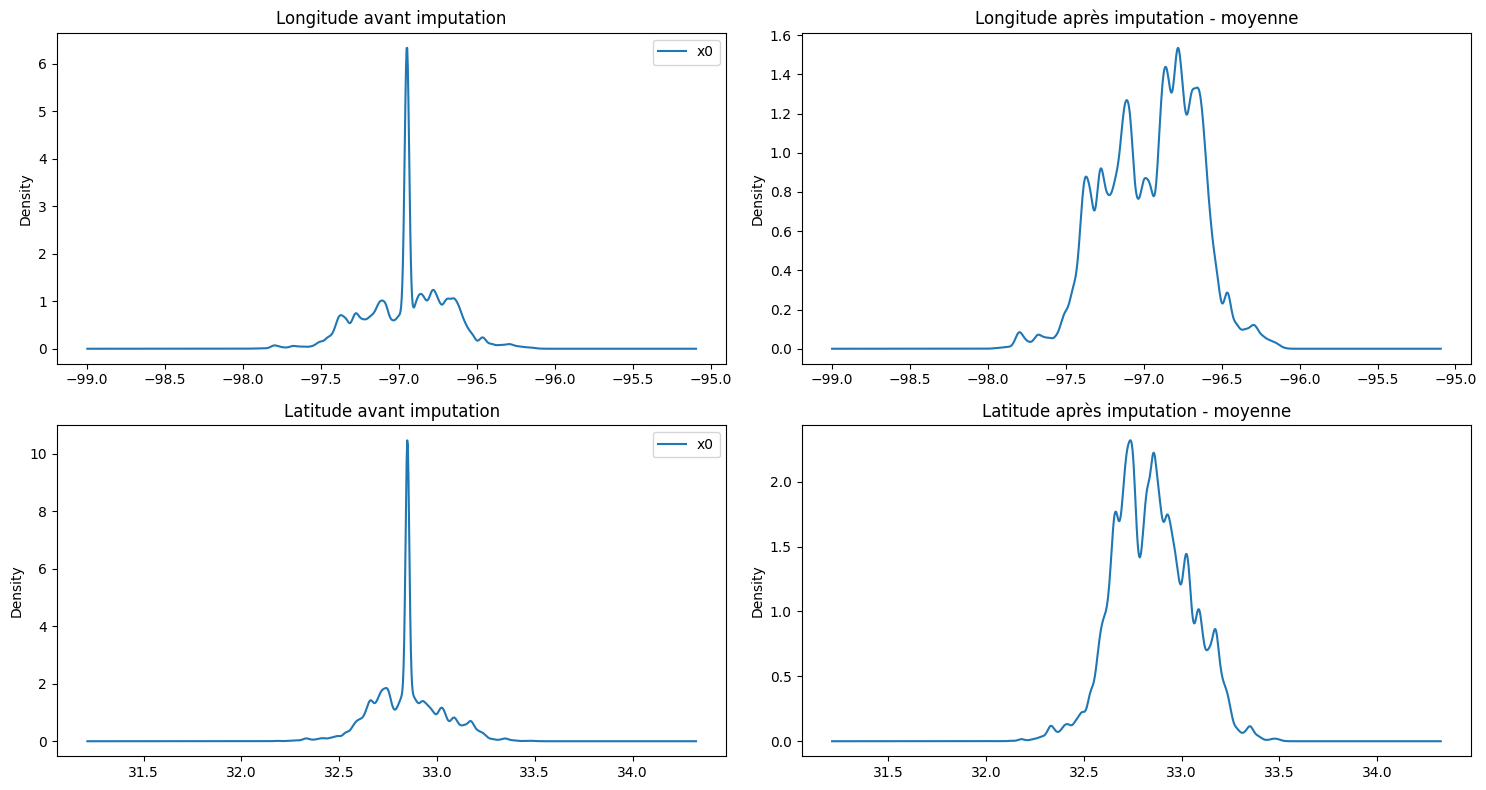

In [85]:
fig, axs = plt.subplots(2, 2, figsize=(15,8))

simple_imp = SimpleImputer(strategy='mean')
simple_imp

long = simple_imp.fit_transform(np.array(df['LONGITUDE']).reshape(-1,1))
lat = simple_imp.fit_transform(np.array(df['LATITUDE']).reshape(-1,1))

long.plot(kind='kde', ax=axs[0, 0])
df['LONGITUDE'].plot(kind='kde', ax=axs[0, 1])
axs[0, 0].set_title('Longitude avant imputation')
axs[0, 1].set_title('Longitude après imputation - moyenne')

lat.plot(kind='kde', ax=axs[1, 0])
df['LATITUDE'].plot(kind='kde', ax=axs[1, 1])
axs[1, 0].set_title('Latitude avant imputation')
axs[1, 1].set_title('Latitude après imputation - moyenne')

plt.tight_layout()
plt.savefig('../ressources/data/2_intermediary/latitude_longitude_imputation.png')
plt.show()

*l'imputation par la moyenne ne change pas la distribution..*

In [86]:
df['LONGITUDE'], df['LATITUDE'] = long, lat
df.head()

,CURR_ANN_AMT,DAYS_TENURE,CUST_ORIG_DATE,AGE_IN_YEARS,DATE_OF_BIRTH,ACCT_SUSPD_DATE,INCOME,HAS_CHILDREN,LENGTH_OF_RESIDENCE,MARITAL_STATUS,HOME_MARKET_VALUE,HOME_OWNER,COLLEGE_DEGREE,GOOD_CREDIT,LATITUDE,LONGITUDE,CITY,COUNTY,churn
0,818.877997,1454.0,2018-12-09,44.474,1978-06-23,None,22500.0,1.0,15.0,Married,50000 - 74999,1.0,1.0,1.0,32.578829,-96.305006,Kaufman,Kaufman,False
1,974.199182,1795.0,2018-01-02,72.559,1950-05-30,None,27500.0,0.0,2.0,Single,50000 - 74999,1.0,0.0,0.0,32.732209,-97.000893,Grand Prairie,Dallas,False
2,967.375112,4818.0,2009-09-23,55.444,1967-07-07,None,42500.0,0.0,10.0,Married,75000 - 99999,1.0,0.0,0.0,32.819777,-96.846938,Dallas,Dallas,False
3,992.409561,130.0,2022-07-25,53.558,1969-05-25,2021-12-22,125000.0,1.0,6.0,Married,175000 - 199999,1.0,0.0,1.0,32.684065,-97.162180,Arlington,Tarrant,True
4,784.633494,5896.0,2006-10-11,50.220,1972-09-25,None,87500.0,1.0,4.0,Married,225000 - 249999,1.0,1.0,1.0,32.751398,-97.376745,Fort Worth,Tarrant,False


In [89]:
df = df.drop(['CUST_ORIG_DATE', 'DATE_OF_BIRTH', 'ACCT_SUSPD_DATE'], axis=1) # on supprime les dates pcq on a des variables dérivées exple : DAYS_TENURE AGE CHURN et btw on est en 2022
compute_insights(df)

Computing entropies..


,null freq,na freq,entropy
churn,0.000,0.000,0.02
GOOD_CREDIT,0.000,0.000,0.03
HOME_OWNER,0.000,0.000,0.04
COLLEGE_DEGREE,0.000,0.000,0.04
HAS_CHILDREN,0.000,0.000,0.05
MARITAL_STATUS,0.204,0.204,0.07
COUNTY,0.007,0.007,0.11
HOME_MARKET_VALUE,0.090,0.090,0.17
INCOME,0.000,0.000,0.18
LENGTH_OF_RESIDENCE,0.000,0.000,0.18


*Enfin on va encoder le target*

In [ ]:
te = ce.TargetEncoder(verbose=2, cols=['churn'])
te.set_output(transform='pandas')
_ = te.fit_transform(df, df['churn'])
_.head()

,CURR_ANN_AMT,DAYS_TENURE,AGE_IN_YEARS,INCOME,HAS_CHILDREN,LENGTH_OF_RESIDENCE,MARITAL_STATUS,HOME_MARKET_VALUE,HOME_OWNER,COLLEGE_DEGREE,GOOD_CREDIT,LATITUDE,LONGITUDE,CITY,COUNTY,churn
0,818.877997,1454.0,44.474,22500.0,1.0,15.0,1,1,1.0,1.0,1.0,32.578829,-96.305006,1,1,0.0
1,974.199182,1795.0,72.559,27500.0,0.0,2.0,2,1,1.0,0.0,0.0,32.732209,-97.000893,2,2,0.0
2,967.375112,4818.0,55.444,42500.0,0.0,10.0,1,2,1.0,0.0,0.0,32.819777,-96.846938,3,2,0.0
3,992.409561,130.0,53.558,125000.0,1.0,6.0,1,3,1.0,0.0,1.0,32.684065,-97.162180,4,3,1.0
4,784.633494,5896.0,50.220,87500.0,1.0,4.0,1,4,1.0,1.0,1.0,32.751398,-97.376745,5,3,0.0


In [ ]:
df['churn'].value_counts()

churn
False    1863290
True      249265
Name: count, dtype: int64

### RESET

In [15]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import category_encoders as ce
import sklearn as skl
from sklearn.impute import SimpleImputer
from ressources.data.description import DESCRIPTIONS
from utils.fonctions import compute_entropies

In [16]:
class Nettoyage:
    "Nettoyage et numérisation."
    def __init__(self, data):
        self.data = data
        self._cols_to_drop = [
            'INDIVIDUAL_ID', 'SOCIAL_SECURITY_NUMBER', 'ADDRESS_ID', 'STREET_ADDRESS', 'STATE'
            ]
        self._dates_to_drop = [
            'CUST_ORIG_DATE', 'DATE_OF_BIRTH', 'ACCT_SUSPD_DATE' # on supprime les dates pcq on a des variables dérivées exple : DAYS_TENURE AGE CHURN et btw on est en 2022
        ]
        
    def compute_insights(self):
        _ = pd.DataFrame(self.data.isnull().sum(), columns=['null freq'])/self.data.shape[0]
        _['na freq'] = self.data.isna().sum()/self.data.shape[0]

        _['entropy'] = pd.DataFrame(compute_entropies(self.data, self.data.columns)).set_index('col')['entropy']
        _ = round(_, 3)

        return _.sort_values(by='entropy')
    
    def compute_target(self):
        "si ta date est dispo => t'as résilié donc isna == not churn"
        assert 'ACCT_SUSPD_DATE' in self.data.columns, "la colonne ACCT_SUSPD_DATE est manquante et sert à compute la target !"
        self.data['churn'] = ~self.data['ACCT_SUSPD_DATE'].isna() 
        return self

    def numerize(self, encoder_pipeline):
        skl.set_config(transform_output='pandas')
        self.data["COUNTY"].replace(to_replace='None', value='N/R', inplace=True)
        self.data["MARITAL_STATUS"].replace('None', 'N/R', inplace=True)
        self.data["HOME_MARKET_VALUE"].replace('None', 'N/R', inplace=True)
        self.data["CITY"].replace('None', 'N/R', inplace=True)
        self.data = encoder_pipeline.fit_transform(self.data)
        return self

    def fillna(self):
        skl.set_config(transform_output='pandas')
        # fig, axs = plt.subplots(2, 2, figsize=(15,8))
        simple_imp = SimpleImputer(strategy='mean')
        long = simple_imp.fit_transform(np.array(df['LONGITUDE']).reshape(-1,1))
        lat = simple_imp.fit_transform(np.array(df['LATITUDE']).reshape(-1,1))

        # long.plot(kind='kde', ax=axs[0, 0])
        # df['LONGITUDE'].plot(kind='kde', ax=axs[0, 1])
        # axs[0, 0].set_title('Longitude avant imputation')
        # axs[0, 1].set_title('Longitude après imputation - moyenne')

        # lat.plot(kind='kde', ax=axs[1, 0])
        # df['LATITUDE'].plot(kind='kde', ax=axs[1, 1])
        # axs[1, 0].set_title('Latitude avant imputation')
        # axs[1, 1].set_title('Latitude après imputation - moyenne')

        # plt.tight_layout()        
        self.data['LONGITUDE_imp'], self.data['LATITUDE_imp'] = long, lat
        return self

    def run(self, numerisation_pipeline):
        # suppr les colonnes 
        self.data = self.data.drop(self._cols_to_drop, axis=1)
        # suppr les 160k qui n'ont pas de caract. socio démo
        _rows_to_drop = self.data[self.data['AGE_IN_YEARS'].isna()].index
        self.data = self.data.drop(_rows_to_drop, axis=0)
        self.data = self.data.reset_index(drop=True)
        # calculer la target à partir de la date de résil et numerisation
        self.fillna().compute_target()
        self.data = self.data.drop(self._dates_to_drop, axis=1)
        self.numerize(numerisation_pipeline)

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')


home_market_value_mapping = {
    "1000 - 24999": 1,
    "25000 - 49999": 2,
    "50000 - 74999": 3,
    "75000 - 99999": 4,
    "100000 - 124999": 5,
    "125000 - 149999": 6,
    "150000 - 174999": 7,
    "175000 - 199999": 8,
    "200000 - 224999": 9,
    "225000 - 249999": 10,
    "250000 - 274999": 11,
    "275000 - 299999": 12,
    "300000 - 349999": 13,
    "350000 - 399999": 14,
    "400000 - 449999": 15,
    "450000 - 499999": 16,
    "500000 - 749999": 17,
    "750000 - 999999": 18,
    "1000000 Plus": 19,
    "NaN": 20
}

num_pipeline = ColumnTransformer([
        ('num_county', ce.BinaryEncoder(base=1+15), ['COUNTY']),
        ('num_marital_status', ce.BinaryEncoder(base=1+3), ['MARITAL_STATUS']),
        ('num_city', ce.BinaryEncoder(base=1+96), ['CITY']),
        ('num_home_market_value', ce.OrdinalEncoder(mapping=[{'col': 'HOME_MARKET_VALUE', 'mapping': home_market_value_mapping}]), ['HOME_MARKET_VALUE']),
        ('encode_target', ce.BinaryEncoder(), ['churn']) # si target encoder mettre à part
    ], remainder='passthrough', verbose_feature_names_out=False)

In [21]:
def load_db():

    return pd.concat([
        pd.read_parquet(r'..\ressources\data\0_archive\Insurance_Churn_ParticipantsData\train\data-0.parquet'),
        pd.read_parquet(r'..\ressources\data\0_archive\Insurance_Churn_ParticipantsData\train\data-1.parquet'),
        pd.read_parquet(r'..\ressources\data\0_archive\Insurance_Churn_ParticipantsData\train\data-2.parquet')
    ], axis=0).drop_duplicates().reset_index(drop=True)

df = load_db()
obj = Nettoyage(df)
obj.run(num_pipeline)

In [22]:
obj.data.head()

,COUNTY_0,MARITAL_STATUS_0,CITY_0,HOME_MARKET_VALUE,churn,CURR_ANN_AMT,DAYS_TENURE,AGE_IN_YEARS,INCOME,HAS_CHILDREN,LENGTH_OF_RESIDENCE,HOME_OWNER,COLLEGE_DEGREE,GOOD_CREDIT,LATITUDE,LONGITUDE,LONGITUDE_imp,LATITUDE_imp
0,1,1,1,3.0,False,818.877997,1454.0,44.474,22500.0,1.0,15.0,1.0,1.0,1.0,32.578829,-96.305006,-96.305006,32.578829
1,2,2,2,3.0,False,974.199182,1795.0,72.559,27500.0,0.0,2.0,1.0,0.0,0.0,32.732209,-97.000893,-97.000893,32.732209
2,2,1,3,4.0,False,967.375112,4818.0,55.444,42500.0,0.0,10.0,1.0,0.0,0.0,32.819777,-96.846938,-96.846938,32.819777
3,3,1,4,8.0,True,992.409561,130.0,53.558,125000.0,1.0,6.0,1.0,0.0,1.0,32.684065,-97.162180,-97.162180,32.684065
4,3,1,5,10.0,False,784.633494,5896.0,50.220,87500.0,1.0,4.0,1.0,1.0,1.0,32.751398,-97.376745,-97.376745,32.751398


In [23]:
with open('../ressources/encoders_fitted/numerisation_pipeline.pkl', 'wb') as f:
    pickle.dump(num_pipeline, f)
num_pipeline

ColumnTransformer(remainder='passthrough',
                  transformers=[('num_county', BinaryEncoder(base=16),
                                 ['COUNTY']),
                                ('num_marital_status', BinaryEncoder(base=4),
                                 ['MARITAL_STATUS']),
                                ('num_city', BinaryEncoder(base=97), ['CITY']),
                                ('num_home_market_value',
                                 OrdinalEncoder(mapping=[{'col': 'HOME_MARKET_VALUE',
                                                          'data_type': dtype('O'),
                                                          'mapping': 1000 - 24999        1
25000 - 49999       2
5000...
75000 - 99999       4
100000 - 124999     5
125000 - 149999     6
150000 - 174999     7
175000 - 199999     8
200000 - 224999     9
225000 - 249999    10
250000 - 274999    11
275000 - 299999    12
300000 - 349999    13
350000 - 399999    14
400000 - 449999    15
450000 - 499999    16
500000 - 749999    17
750000 - 999999    18
1000000 Plus       19
NaN                20
dtype: int64}]),
                                 ['HOME_MARKET_VALUE']),
                                ('encode_target', BinaryEncoder(), ['churn'])],
                  verbose_feature_names_out=False)

In [24]:
obj.data.to_parquet(r'..\ressources\data\0_archive\Insurance_Churn_ParticipantsData\train\data-numerized.parquet', compression='gzip')

# Dataviz (reset)

In [2]:
import sys
sys.path.append('..')
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt, pickle
from ressources.data.description import DESCRIPTIONS

df = pd.read_parquet(r'..\ressources\data\0_archive\Insurance_Churn_ParticipantsData\train\data-numerized.parquet')
num_pipeline = pickle.load(open(r'../ressources/encoders_fitted/numerisation_pipeline.pkl', 'rb'))

In [27]:
# enc_pipeline.transformers_[0][1].inverse_transform(df[['COUNTY_0']].head())
list(num_pipeline.transformers_[0][1].get_feature_names_out())

['COUNTY_0']

In [28]:
# reverse transformation
def reverse_transform(df, enc_pipeline):
	df_copy = df.copy()
	for name, transformer, columns in enc_pipeline.transformers_:
		print(name)
		if hasattr(transformer, 'inverse_transform') and (name != 'remainder'):
			output_cols = list(transformer.get_feature_names_out())
			for i,o in zip(columns, output_cols):
				df_copy[i] = transformer.inverse_transform(df_copy[o])
	return df_copy

original_data = reverse_transform(df, num_pipeline)
original_data.head()

num_county
num_marital_status
num_city
num_home_market_value
encode_target
remainder


,COUNTY_0,MARITAL_STATUS_0,CITY_0,HOME_MARKET_VALUE,churn,CURR_ANN_AMT,DAYS_TENURE,AGE_IN_YEARS,INCOME,HAS_CHILDREN,...,HOME_OWNER,COLLEGE_DEGREE,GOOD_CREDIT,LATITUDE,LONGITUDE,LONGITUDE_imp,LATITUDE_imp,COUNTY,MARITAL_STATUS,CITY
0,1,1,1,50000 - 74999,False,818.877997,1454.0,44.474,22500.0,1.0,...,1.0,1.0,1.0,32.578829,-96.305006,-96.305006,32.578829,Kaufman,Married,Kaufman
1,2,2,2,50000 - 74999,False,974.199182,1795.0,72.559,27500.0,0.0,...,1.0,0.0,0.0,32.732209,-97.000893,-97.000893,32.732209,Dallas,Single,Grand Prairie
2,2,1,3,75000 - 99999,False,967.375112,4818.0,55.444,42500.0,0.0,...,1.0,0.0,0.0,32.819777,-96.846938,-96.846938,32.819777,Dallas,Married,Dallas
3,3,1,4,175000 - 199999,True,992.409561,130.0,53.558,125000.0,1.0,...,1.0,0.0,1.0,32.684065,-97.162180,-97.162180,32.684065,Tarrant,Married,Arlington
4,3,1,5,225000 - 249999,False,784.633494,5896.0,50.220,87500.0,1.0,...,1.0,1.0,1.0,32.751398,-97.376745,-97.376745,32.751398,Tarrant,Married,Fort Worth


In [38]:
mapping_hmv = pd.read_pickle('../ressources/data/2_intermediary/encoding_home_market_value.pkl')
mapping_hmv

,mapping
1000 - 24999,1
25000 - 49999,2
50000 - 74999,3
75000 - 99999,4
100000 - 124999,5
125000 - 149999,6
150000 - 174999,7
175000 - 199999,8
200000 - 224999,9
225000 - 249999,10


Text(0.5, 1.0, 'TARGET RESILIATION (CHURN) - 1: résilié, 0: non résilié')

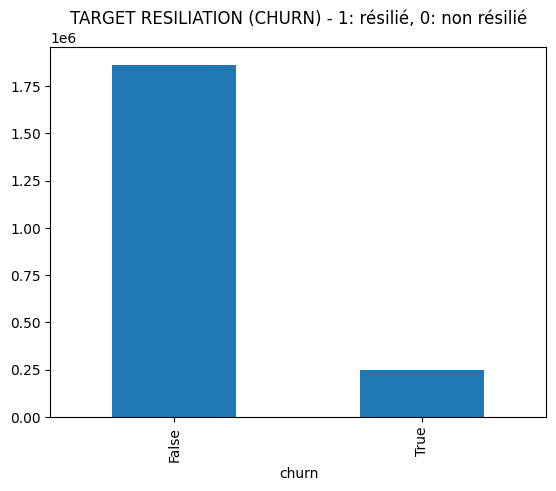

In [42]:
df.churn.value_counts().plot(kind='bar').set_title('TARGET RESILIATION (CHURN) - 1: résilié, 0: non résilié')

Text(0.5, 1.0, 'AGE_IN_YEARS')

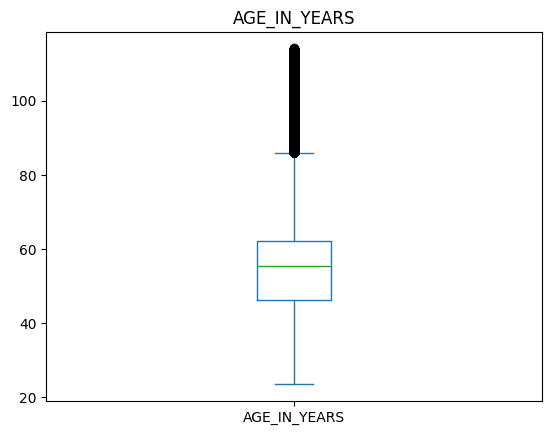

In [5]:
df.AGE_IN_YEARS.plot(kind='box').set_title('AGE_IN_YEARS')

In [ ]:
# Calculate the median and IQR for AGE_IN_YEARS
Q1 = df['AGE_IN_YEARS'].quantile(0.25)
Q3 = df['AGE_IN_YEARS'].quantile(0.75)
IQR = Q3 - Q1
median = df['AGE_IN_YEARS'].median()

# Define the upper bound
upper_bound = median + 1.5 * IQR
upper_bound # mathce avec l'espérance de vie en 2022 ~ 77 ans 

79.321

In [7]:
df = df[df['AGE_IN_YEARS'] <= upper_bound]
df = df.reset_index(drop=True)

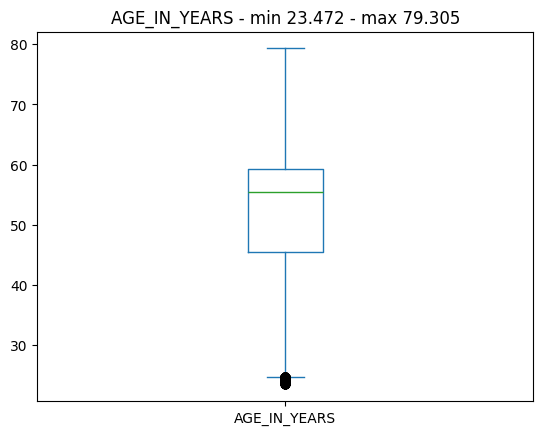

In [14]:
df.AGE_IN_YEARS.plot(kind='box').set_title(f'AGE_IN_YEARS - min {df.AGE_IN_YEARS.min()} - max {df.AGE_IN_YEARS.max()}')
plt.savefig('../ressources/data/2_intermediary/boxplot_age_cleaned.png')

In [ ]:
def compute_pearson_correlation(df):
    """
    Calcule la corrélation de Pearson entre toutes les colonnes numériques d'un DataFrame.

    :param df: pd.DataFrame, DataFrame contenant les colonnes à analyser.
    :return: pd.DataFrame, matrice des corrélations de Pearson.
    """
    # Sélectionner uniquement les colonnes numériques (float ou int)
    numeric_df = df.select_dtypes(include=['float64', 'int64'])
    
    # Calcul de la matrice de corrélation
    correlation_matrix = numeric_df.corr(method='pearson')
    return correlation_matrix

def plot_upper_half_correlation_matrix(correlation_matrix):
    """
    Affiche une heatmap de la moitié supérieure d'une matrice de corrélation.
    :param correlation_matrix: pd.DataFrame, matrice des corrélations de Pearson.
    """
    # Masquer la moitié inférieure de la matrice\n",
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    plt.figure(figsize=(10, 8))
    # Plot de la heatmap avec masque",
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', 
                fmt='.2f', cbar_kws={'shrink': 0.8}, square=True, linewidths=0.5)
    plt.title('Upper Half of Pearson Correlation Matrix', fontsize=16)
    plt.show()

plot_upper_half_correlation_matrix(compute_pearson_correlation(df))

In [ ]:
from scipy.stats import f_oneway

# sep the data into two groups based on the target variable 'churn'
grouped_data = df.groupby('churn')

# ANOVA for each numerical feature
anova_results = {}
for column in df.select_dtypes(include=['float64', 'int64']).columns:
    if column != 'churn':
        group_0 = grouped_data.get_group(False)[column]
        group_1 = grouped_data.get_group(True)[column]
        f_stat, p_value = f_oneway(group_0, group_1)
        anova_results[column] = {'f_stat': f_stat, 'p_value': p_value}

anova_results

{'COUNTY_0': {'f_stat': 1.2861445465035213, 'p_value': 0.2567598078127138},
 'MARITAL_STATUS_0': {'f_stat': 612.7198333072971,
  'p_value': 2.995959159529921e-135},
 'CITY_0': {'f_stat': 2.954400413158196, 'p_value': 0.08564421435053637},
 'HOME_MARKET_VALUE': {'f_stat': 151.6922732551749,
  'p_value': 7.417892648140229e-35},
 'CURR_ANN_AMT': {'f_stat': 1016.587910832692,
  'p_value': 5.0336439762167874e-223},
 'DAYS_TENURE': {'f_stat': 101987.95938355994, 'p_value': 0.0},
 'AGE_IN_YEARS': {'f_stat': 5529.595305702479, 'p_value': 0.0},
 'INCOME': {'f_stat': 85.94864378346674, 'p_value': 1.848350567140718e-20},
 'HAS_CHILDREN': {'f_stat': 245.66824190759513,
  'p_value': 2.301236373547844e-55},
 'LENGTH_OF_RESIDENCE': {'f_stat': 2603.0781521606204, 'p_value': 0.0},
 'HOME_OWNER': {'f_stat': 750.4454782025072,
  'p_value': 3.4320420164491884e-165},
 'COLLEGE_DEGREE': {'f_stat': 889.8568322273217,
  'p_value': 1.728278833906193e-195},
 'GOOD_CREDIT': {'f_stat': 142.9814830311585,
  'p_val

In [51]:
pd.DataFrame(anova_results).T.to_pickle('../ressources/data/2_intermediary/anova_results.pkl')

# interprétation des résultats
# si p-value < 0.05 => on rejette l'hypothèse nulle (H0) => les moyennes des deux groupes sont différentes
# si p-value > 0.05 => on ne rejette pas l'hypothèse nulle (H0) => les moyennes des deux groupes sont similaires

In [ ]:
df['churn'] = ce.BinaryEncoder().fit_transform(df['churn'].astype('str'))['churn_0']
df['LATITUDE'] = df['LATITUDE_imp']
df['LONGITUDE'] = df['LONGITUDE_imp']
df = df.drop(['LATITUDE_imp', 'LONGITUDE_imp'], axis=1)

In [23]:
df.to_parquet(r'..\ressources\data\0_archive\Insurance_Churn_ParticipantsData\train\data-cleaned.parquet')

**Conclusion :** *On a supprimé les personnes dont les ages sont trop grands (plus grands que 80 ans) car on suppose que ces ages sont des valeurs abérrantes au regard de la problématique. De plus la variable target est déséquilibrée entre les 2 modalités 1 et 0.*

# Comparer à la data du hackathon

*Le but ici est de comparer les distributions des variables anonymisées à celles des variables du dataset simulé que nous avons traité jusque là pour pouvoir établir une correspondance entre les données réelles et les données simulées.*

*On modélise une loi donnée par sa fonction de répartition F (voir courbe rouge sur la figure). La fonction de répartition associe à tout x (en abscisses), la probabilité qu'une variable suivant cette loi soit plus petite que x (en ordonnées). Le test consiste alors à comparer la fonction de répartition de la loi (fonction de répartition théorique) à la fonction de répartition empirique Fn (en bleu). Cette dernière est une fonction de répartition obtenue en attribuant la probabilité 1/n à chacun des n éléments de l'échantillon.* 

*On mesure alors la différence entre les deux courbes. Si cette différence est inférieure à un seuil, alors on décide que l'échantillon provient bien de cette loi donnée. Plus précisément, on rejette l'hypothèse que l'échantillon provienne de la loi s'il y a une valeur de x pour laquelle |Fn(x) - F(x)| est grande.*

In [2]:
import pandas as pd

real_db_path = r'..\ressources\data\0_archive\Insurance_Churn_ParticipantsData\real\Train.csv'
real_db = pd.read_csv(real_db_path)
real_db.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,labels
0,-0.276515,-0.424429,1.344997,-0.012283,0.076230,1.076648,0.182198,3,0,1,0,0,0,0,10,2,1
1,0.853573,0.150991,0.503892,-0.979179,-0.569351,-0.411453,-0.251940,4,1,2,0,1,0,0,0,3,0
2,0.947747,-0.173832,1.825628,-0.703478,0.076230,-0.411453,-0.251940,6,1,2,0,0,0,0,5,3,0
3,0.853573,-0.381404,0.984523,-0.039464,-0.569351,-0.411453,-0.251940,4,0,2,0,1,0,0,5,3,0
4,1.324443,1.590527,-1.178318,-0.097711,-0.246560,-0.411453,-0.251940,0,1,1,0,0,0,0,8,3,0


In [3]:
import numpy as np
import category_encoders as ce
from scipy.stats import ks_2samp

In [32]:
df = pd.read_parquet(r'..\ressources\data\0_archive\Insurance_Churn_ParticipantsData\train\data-cleaned.parquet')

### Entre les targets

In [6]:
ks_stat, p_value = ks_2samp(df['churn'], real_db['labels'])

print(f"Variable réelle labels correspond probablement à churn : p_value du test : {round(p_value, 3)} (KS stat = {ks_stat:.4f})")

# regle de decision : si p_value < 0.05 => on rejette l'hypothèse nulle (H0) => les deux distributions sont différentes
# si p_value > 0.05 => on ne rejette pas l'hypothèse nulle (H0) => les deux distributions sont similaires

Variable réelle labels correspond probablement à churn : p_value du test : 0.744 (KS stat = 0.0037)


<Axes: title={'center': 'hackathon - target'}, xlabel='labels'>

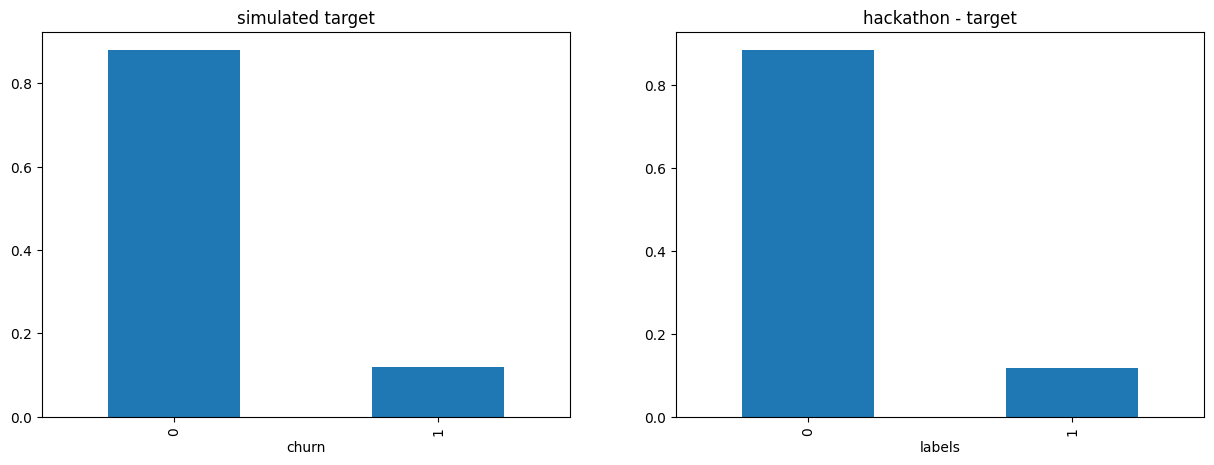

In [15]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
df.churn.value_counts(normalize=True).plot(kind='bar', ax=axs[0], title='simulated target')
real_db.labels.value_counts(normalize=True).plot(kind='bar', ax=axs[1], title='hackathon - target')

### Entre les features

In [16]:
df_real = real_db.copy()
df_simulated = df.copy()

# Créer une matrice de p-values
p_values_matrix = pd.DataFrame(index=df_real.columns, columns=df_simulated.columns)
d_matrix = pd.DataFrame(index=df_real.columns, columns=df_simulated.columns)

# Calculer les p-values pour chaque paire de variables
for real_col in df_real.columns:
    for sim_col in df_simulated.columns:
        # if np.issubdtype(df_real[real_col].dtype, np.number) and np.issubdtype(df_simulated[sim_col].dtype, np.number):
        _, p_value = ks_2samp(df_real[real_col].dropna(), df_simulated[sim_col].dropna())
        p_values_matrix.loc[real_col, sim_col] = round(p_value, 4)
        d_matrix.loc[real_col, sim_col] = round(_, 4)

In [17]:
p_values_matrix

,COUNTY_0,MARITAL_STATUS_0,CITY_0,HOME_MARKET_VALUE,churn,CURR_ANN_AMT,DAYS_TENURE,AGE_IN_YEARS,INCOME,HAS_CHILDREN,LENGTH_OF_RESIDENCE,HOME_OWNER,COLLEGE_DEGREE,GOOD_CREDIT,LATITUDE,LONGITUDE
feature_0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
feature_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
feature_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
feature_3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
feature_4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
feature_5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
feature_6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
feature_7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
feature_8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
feature_9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
d_matrix

,COUNTY_0,MARITAL_STATUS_0,CITY_0,HOME_MARKET_VALUE,churn,CURR_ANN_AMT,DAYS_TENURE,AGE_IN_YEARS,INCOME,HAS_CHILDREN,LENGTH_OF_RESIDENCE,HOME_OWNER,COLLEGE_DEGREE,GOOD_CREDIT,LATITUDE,LONGITUDE
feature_0,0.9609,0.8167,0.976,0.8691,0.5488,1.0,1.0,1.0,1.0,0.5488,0.7895,0.5488,0.5488,0.6353,1.0,1.0
feature_1,0.9491,0.924,0.9642,0.8573,0.7395,0.9999,0.9999,0.9999,1.0,0.7395,0.8057,0.7395,0.7395,0.7426,1.0,1.0
feature_2,0.9818,0.8054,0.9968,0.89,0.485,1.0,1.0,1.0,1.0,0.485,0.8103,0.4949,0.485,0.624,1.0,1.0
feature_3,0.9354,0.8874,0.9504,0.8436,0.6681,1.0,1.0,1.0,1.0,0.6681,0.7692,0.6681,0.6681,0.706,1.0,1.0
feature_4,0.9417,0.9042,0.9568,0.8499,0.6652,1.0,1.0,1.0,1.0,0.6652,0.7859,0.6652,0.6652,0.7228,1.0,1.0
feature_5,0.9033,0.8673,0.9331,0.8115,0.8235,1.0,1.0,1.0,1.0,0.8235,0.8235,0.8235,0.8235,0.8235,1.0,1.0
feature_6,0.9589,0.9261,0.974,0.8671,0.8184,1.0,1.0,1.0,1.0,0.8184,0.8184,0.8184,0.8184,0.8184,1.0,1.0
feature_7,0.3114,0.6097,0.524,0.2196,0.7645,1.0,1.0,1.0,1.0,0.6704,0.2404,0.6704,0.6704,0.6704,1.0,1.0
feature_8,0.6976,0.2302,0.9707,0.8382,0.7661,1.0,1.0,1.0,1.0,0.4434,0.7326,0.2842,0.5894,0.2842,1.0,1.0
feature_9,0.6461,0.1788,0.9292,0.7967,0.7275,1.0,1.0,1.0,1.0,0.4047,0.6911,0.3356,0.5508,0.3356,1.0,1.0


In [19]:
# Drop the index 'labels'
d_matrix0 = d_matrix.drop(index='labels')

# Highlight the lower value for each column
d_matrix0 = d_matrix0.apply(lambda x: ['match' if v == x.min() else '' for v in x], axis=0)

d_matrix0

,COUNTY_0,MARITAL_STATUS_0,CITY_0,HOME_MARKET_VALUE,churn,CURR_ANN_AMT,DAYS_TENURE,AGE_IN_YEARS,INCOME,HAS_CHILDREN,LENGTH_OF_RESIDENCE,HOME_OWNER,COLLEGE_DEGREE,GOOD_CREDIT,LATITUDE,LONGITUDE
feature_0,,,,,,,,,match,,,,,,match,match
feature_1,,,,,,match,match,match,match,,,,,,match,match
feature_2,,,,,,,,,match,,,,,,match,match
feature_3,,,,,,,,,match,,,,,,match,match
feature_4,,,,,,,,,match,,,,,,match,match
feature_5,,,,,,,,,match,,,,,,match,match
feature_6,,,,,,,,,match,,,,,,match,match
feature_7,match,,,match,,,,,match,,match,,,,match,match
feature_8,,,,,,,,,match,,,,,,match,match
feature_9,,match,,,,,,,match,,,,,,match,match


In [21]:
import pickle

with open('../ressources/data/3_cleaned/ks_features_pvalues.pkl', 'wb') as f:
    pickle.dump(p_values_matrix, f)

with open('../ressources/data/3_cleaned/ks_features_distances.pkl', 'wb') as f:
    pickle.dump(d_matrix, f)

with open('../ressources/data/3_cleaned/ks_features_mindistances.pkl', 'wb') as f:
    pickle.dump(d_matrix0, f)

# Conclusion

Aucune pvaleur n'est supérieure au seuil de 5% ; il n'y a pas assez de preuves pour affirmer que les features du hackathon et celles du dataset simulés proviennent du même échantillon. Dans le dernier notebook, nous allons entrainer puis évaluer les modèles et re essayer de voir si avec un preprocessing, on a de meilleurs resultats sur le test de KS.

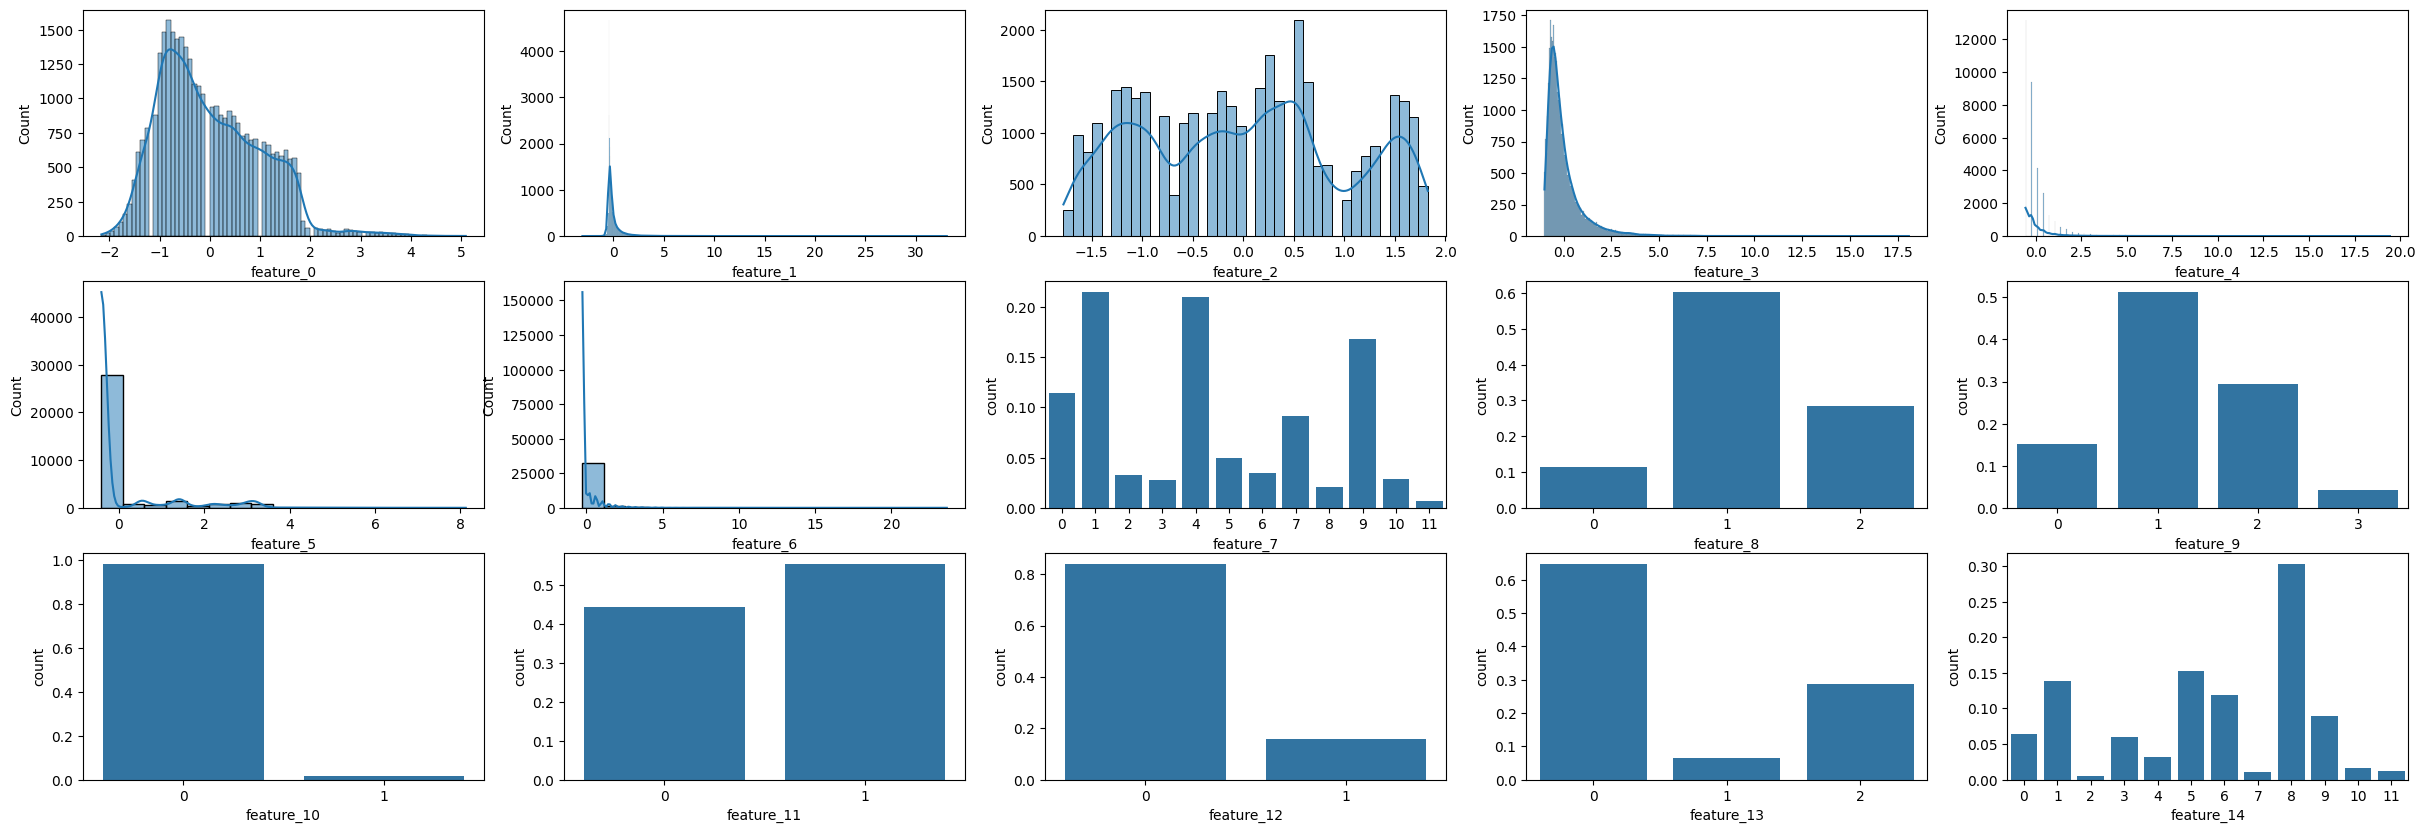

In [22]:
import seaborn as sns
from itertools import product

fig, axs = plt.subplots(3, 5, figsize=(30, 10))
idx = list(product(range(3), range(5)))

for i, c in zip(idx, real_db.columns):
    if int(c.split('_')[-1]) in range(7):
        sns.histplot(real_db[c], kde=True, ax=axs[i[0], i[1]])
    else:
        sns.barplot(real_db[c].value_counts(dropna=False)/real_db.shape[0], ax=axs[i[0], i[1]])

c:\Users\gbeno\Documents\m2_deng\machine_learning\venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\gbeno\Documents\m2_deng\machine_learning\venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\gbeno\Documents\m2_deng\machine_learning\venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\gbeno\Documents\m2_deng\machine_learning\venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\gbeno\Documents\m2_deng\machine_learning\venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, me

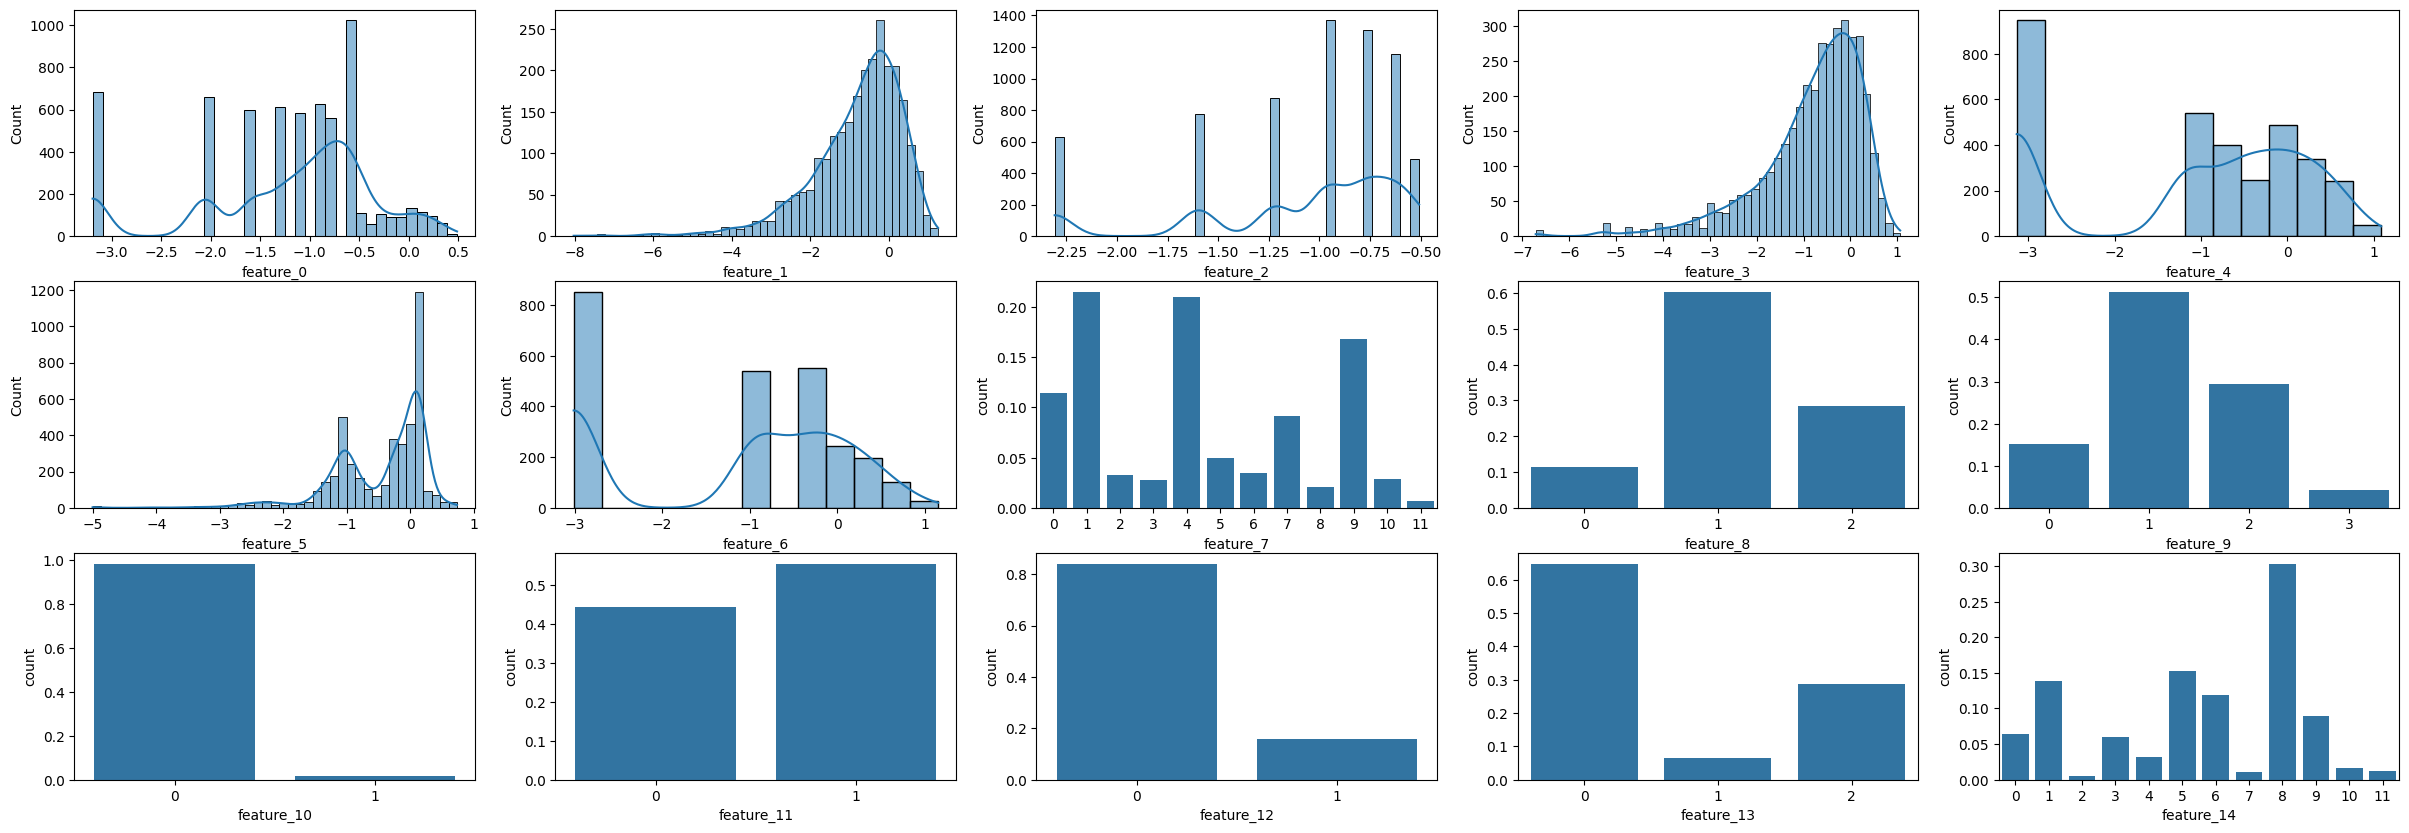

In [24]:
fig, axs = plt.subplots(3, 5, figsize=(30, 10))
idx = list(product(range(3), range(5)))

for i, c in zip(idx, real_db.columns):
    if int(c.split('_')[-1]) in range(7):
        real_db[c] = np.log(real_db[c])
        sns.histplot(real_db[c], kde=True, ax=axs[i[0], i[1]])
    else:
        sns.barplot(real_db[c].value_counts(dropna=False)/real_db.shape[0], ax=axs[i[0], i[1]])

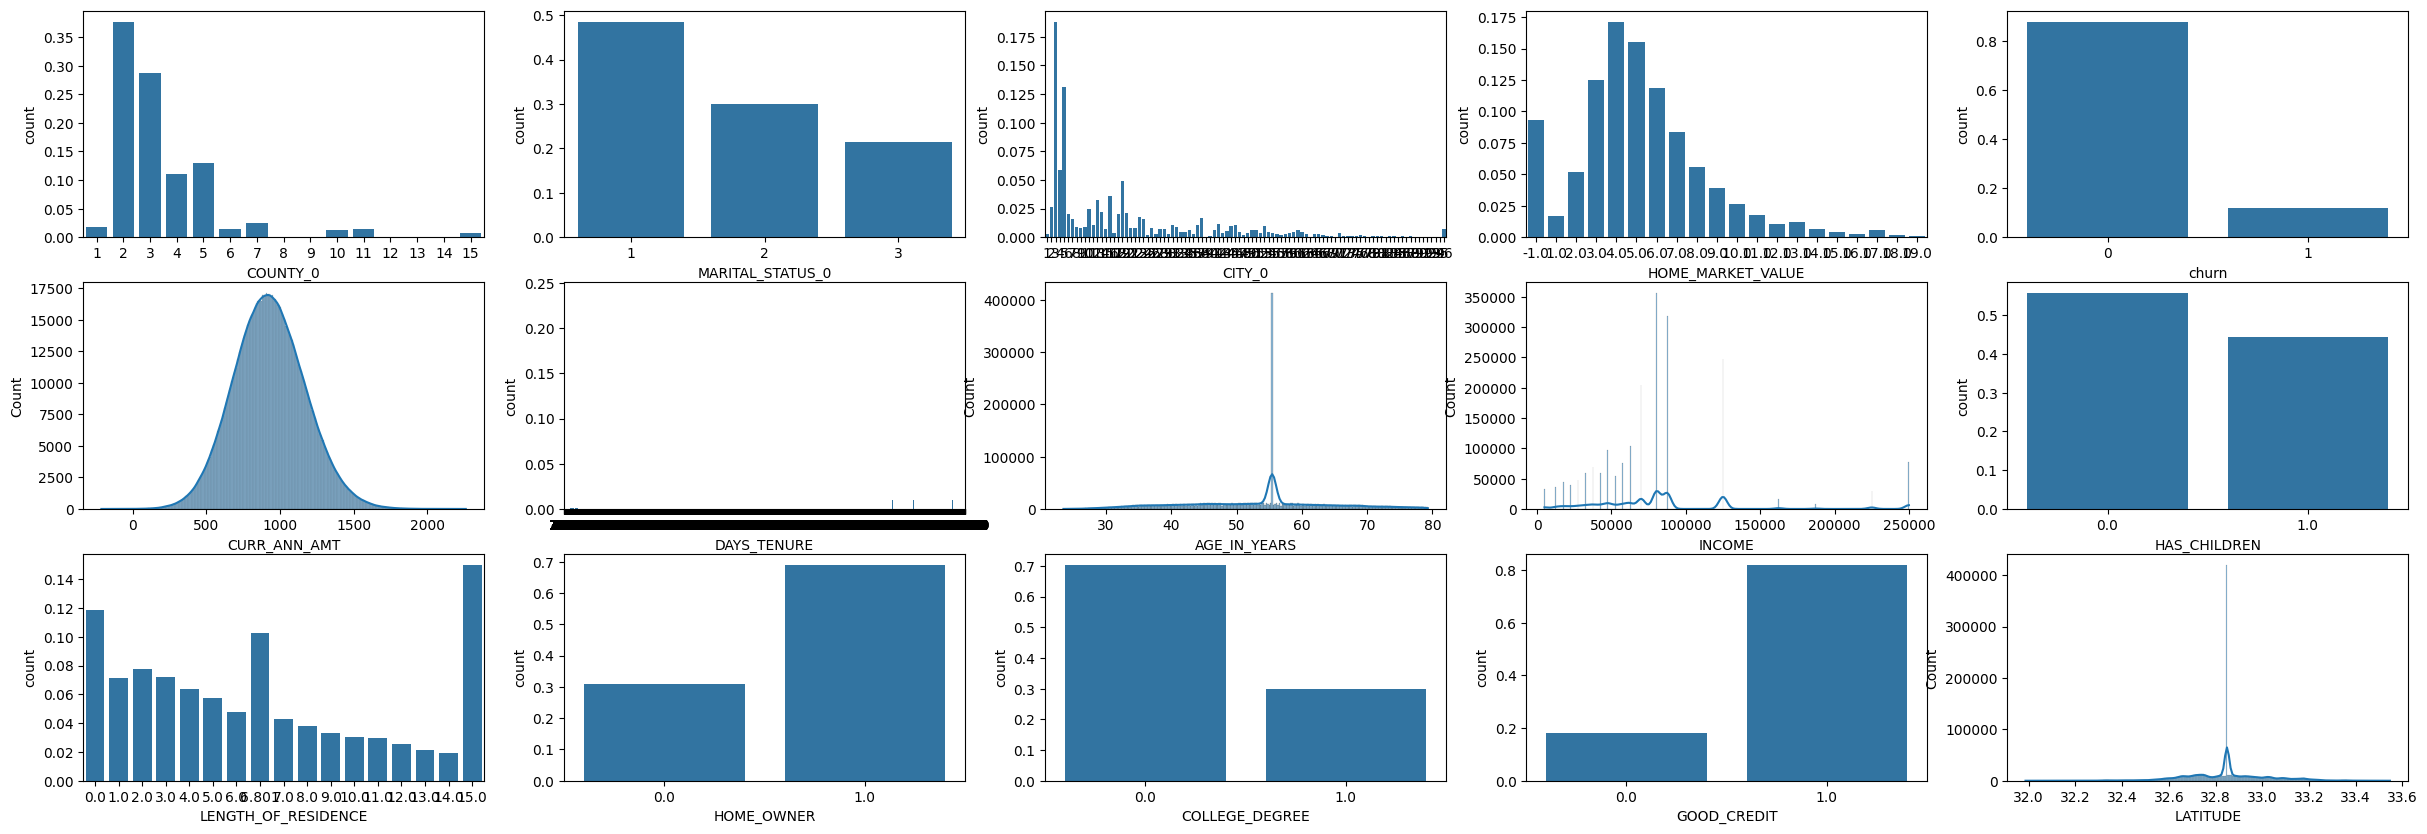

In [ ]:
_num_cols = [
    'INCOME', 'CURR_ANN_AMT',
    'AGE_IN_YEARS', 'DAYS_TENURE', 
    'LATITUDE', 'LONGITUDE'
]

fig, axs = plt.subplots(3, 5, figsize=(30, 10))
idx = list(product(range(3), range(5)))

for i, c in zip(idx, df.columns):
    if c in _num_cols:
        sns.histplot(df[c], kde=True, ax=axs[i[0], i[1]])
    else:
        sns.barplot(df[c].value_counts()/df.shape[0], ax=axs[i[0], i[1]])

<Axes: xlabel='HOME_MARKET_VALUE'>

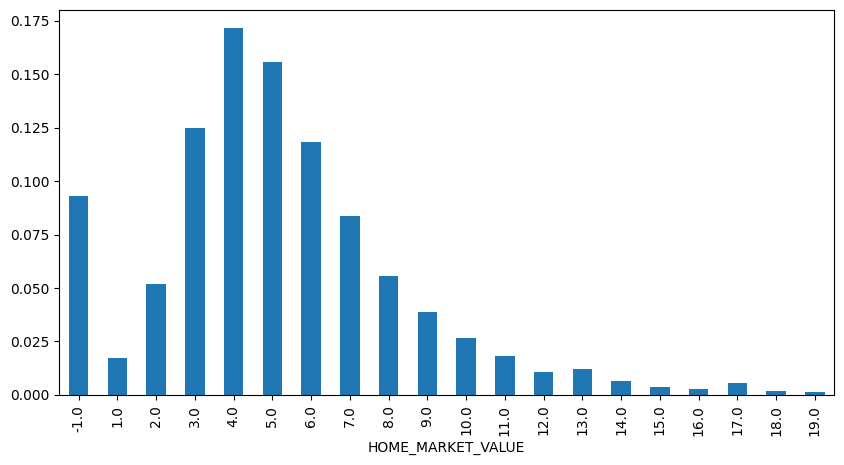

In [31]:
plt.figure(figsize=(10,5))
df.HOME_MARKET_VALUE.value_counts(normalize=True).sort_index().plot(kind='bar')